# Regresión Lineal — Predicción de precio de vuelos

En este notebook vamos a construir un modelo de regresión lineal **desde cero**, sin usar ninguna librería de ML.

**Pregunta que queremos responder:**
> ¿Puedo predecir el precio de un vuelo sabiendo la distancia en kilómetros?

---
**Solo usaremos:** `numpy` y `matplotlib`

## 1. Features

Tenemos registros de vuelos con su distancia (km) y precio promedio del pasaje (USD).

| Ruta | Distancia (km) | Precio (USD) |
|------|---------------|-------------|
| CDMX → Chihuaha | 650 | 85 |
| CDMX → Holox | 1050 | 130 |
| CDMX → Tampico | 1600 | 195 |
| CDMX → Tulum | 1440 | 175 |
| CDMX → Baja California | 3080 | 370 |
| CDMX → Oaxaca | 1360 | 165 |
| CDMX → Puebla | 1230 | 150 |
| CDMX → Tabasco | 1170 | 142 |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Distancia en km (feature)
distancia = np.array([650, 1050, 1600, 1440, 3080, 1360, 1230, 1170], dtype=float)

# Precio en USD (target / variable que queremos predecir)
precio = np.array([85, 130, 195, 175, 370, 165, 150, 142], dtype=float)

print("Distancias (km):", distancia)
print("Precios (USD):  ", precio)

Distancias (km): [ 650. 1050. 1600. 1440. 3080. 1360. 1230. 1170.]
Precios (USD):   [ 85. 130. 195. 175. 370. 165. 150. 142.]


## 2. Visualizar los datos

Antes de ajustar cualquier modelo, siempre miramos los datos.

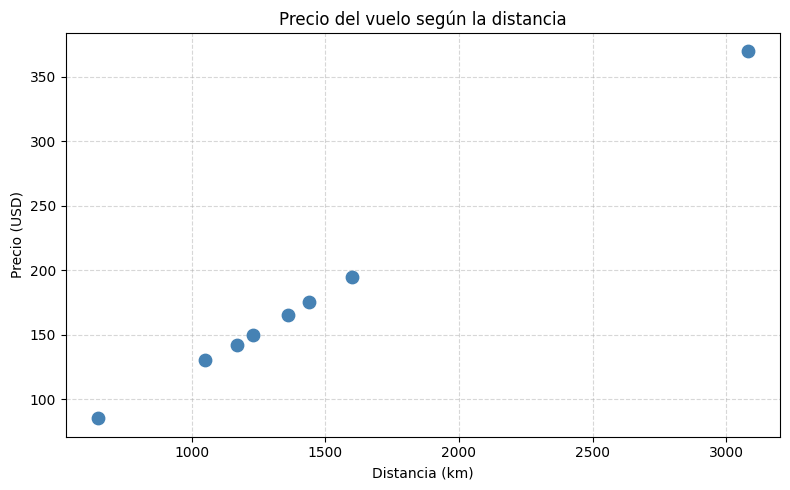

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(distancia, precio, color='steelblue', s=80, zorder=5)
plt.xlabel("Distancia (km)")
plt.ylabel("Precio (USD)")
plt.title("Precio del vuelo según la distancia")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. El modelo — ¿Qué es una recta?

Queremos encontrar una **recta** que pase lo más cerca posible de todos los puntos.

$$\hat{y} = w_1 \cdot x + w_0$$

| Símbolo | Significado |
|---------|------------|
| $x$ | distancia del vuelo (lo que conocemos) |
| $\hat{y}$ | precio predicho |
| $w_1$ | pendiente — cuánto sube el precio por cada km adicional |
| $w_0$ | intercepto — precio base cuando distancia = 0 |

Nuestro trabajo es encontrar los valores de $w_1$ y $w_0$.

## 4. Función de coste — ¿Qué tan mala es nuestra recta?

Para saber si una recta es buena o mala, medimos el **Error Cuadrático Medio (MSE)**:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

- Tomamos cada punto real ($y_i$) y le restamos nuestra predicción ($\hat{y}_i$).
- Lo elevamos al cuadrado para que los errores positivos y negativos no se cancelen.
- Promediamos todo.

**Cuanto menor sea el MSE, mejor es nuestro modelo.**

In [ ]:
def predecir(distancia, w1, w0):
    """Calcula el precio predicho para cada distancia."""
    return w1 * distancia + w0

def mse(y_real, y_pred):
    """Calcula el Error Cuadrático Medio."""
    return np.mean((y_real - y_pred) ** 2)

# Probamos una recta al azar para ver qué pasa
w1_prueba = 0.1   # $0.10 por km
w0_prueba = 10    # precio base $10

y_pred_prueba = predecir(distancia, w1_prueba, w0_prueba)
error_prueba = mse(precio, y_pred_prueba)

print(f"Con w1={w1_prueba}, w0={w0_prueba}")
print(f"MSE = {error_prueba:.2f}")
print("\nPrecios reales vs predichos:")
for real, pred in zip(precio, y_pred_prueba):
    print(f"  Real: ${real:.0f}  →  Predicho: ${pred:.0f}  (error: ${abs(real-pred):.0f})")

Con w1=0.1, w0=10
MSE = 621.25

Precios reales vs predichos:
  Real: $85  →  Predicho: $75  (error: $10)
  Real: $130  →  Predicho: $115  (error: $15)
  Real: $195  →  Predicho: $170  (error: $25)
  Real: $175  →  Predicho: $154  (error: $21)
  Real: $370  →  Predicho: $318  (error: $52)
  Real: $165  →  Predicho: $146  (error: $19)
  Real: $150  →  Predicho: $133  (error: $17)
  Real: $142  →  Predicho: $127  (error: $15)


## 5. Encontrar los mejores pesos — Ecuación Normal

En lugar de probar valores al azar, e intentar a prueba y error para ver que el valor 'predicho' se acerque a lo real existe una fórmula exacta para encontrar el $w_1$ y $w_0$ óptimos.

Se llama la **ecuación normal** y es la solución analítica de la regresión lineal simple:

$$w_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$$

$$w_0 = \bar{y} - w_1 \cdot \bar{x}$$

Donde $\bar{x}$ y $\bar{y}$ son los promedios de x e y.

In [ ]:
def ecuacion_normal(x, y):
    """Calcula w1 y w0 óptimos con la ecuación normal."""
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    w1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    w0 = y_mean - w1 * x_mean

    return w1, w0

w1_opt, w0_opt = ecuacion_normal(distancia, precio)

print(f"Pesos óptimos encontrados:")
print(f"  w1 (pendiente)  = {w1_opt:.4f}  → por cada km extra, el precio sube ${w1_opt:.4f}")
print(f"  w0 (intercepto) = {w0_opt:.2f}  → precio base estimado")

y_pred_opt = predecir(distancia, w1_opt, w0_opt)
print(f"\nMSE con pesos óptimos = {mse(precio, y_pred_opt):.2f}")

Pesos óptimos encontrados:
  w1 (pendiente)  = 0.1180  → por cada km extra, el precio sube $0.1180
  w0 (intercepto) = 5.68  → precio base estimado

MSE con pesos óptimos = 1.69


## 6. Visualizar la recta ajustada

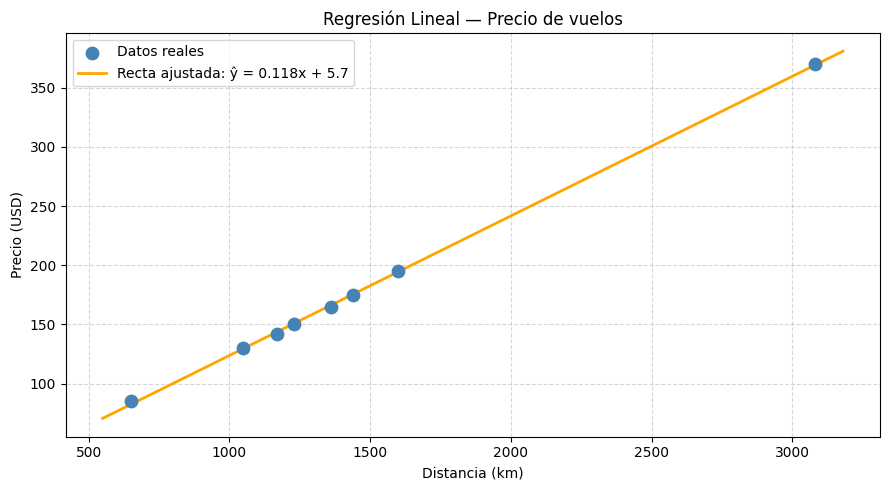

Las líneas rojas son los errores (residuos): distancia entre el punto real y la recta.


In [ ]:
x_linea = np.linspace(distancia.min() - 100, distancia.max() + 100, 200)
y_linea = predecir(x_linea, w1_opt, w0_opt)

plt.figure(figsize=(9, 5))

# Líneas de error (residuos)
for xi, yi, yi_pred in zip(distancia, precio, y_pred_opt):
    plt.plot([xi, xi], [yi, yi_pred], color='tomato', linewidth=1, linestyle='--', alpha=0.7)

plt.scatter(distancia, precio, color='steelblue', s=80, zorder=5, label='Datos reales')
plt.plot(x_linea, y_linea, color='orange', linewidth=2, label=f'Recta ajustada: ŷ = {w1_opt:.3f}x + {w0_opt:.1f}')

plt.xlabel("Distancia (km)")
plt.ylabel("Precio (USD)")
plt.title("Regresión Lineal — Precio de vuelos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Las líneas rojas son los errores (residuos): distancia entre el punto real y la recta.")

## 7. Hacer una predicción

Ahora podemos predecir el precio de cualquier vuelo, solo conociendo la distancia.

In [ ]:
# Nuevas rutas que no estaban en los datos
nuevas_rutas = {
    "CDMX → Hidalgo": 400,
    "CDMX → Veracruz": 900,
    "CDMX → Colombia": 3600,
}

print("Predicciones para nuevas rutas:")
print("-" * 48)
for ruta, km in nuevas_rutas.items():
    precio_pred = predecir(km, w1_opt, w0_opt)
    print(f"  {ruta}")
    print(f"  Distancia: {km} km  →  Precio estimado: ${precio_pred:.0f}")
    print()

Predicciones para nuevas rutas:
------------------------------------------------
  CDMX → Hidalgo
  Distancia: 400 km  →  Precio estimado: $53

  CDMX → Veracruz
  Distancia: 900 km  →  Precio estimado: $112

  CDMX → Colombia
  Distancia: 3600 km  →  Precio estimado: $431



## 8. ¿Qué tan bueno es el modelo? — R²

El **coeficiente de determinación R²** mide qué proporción de la variación del precio es explicada por la distancia.

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

- $R^2 = 1$ → el modelo explica todo perfectamente
- $R^2 = 0$ → el modelo no explica nada

In [ ]:
def r2(y_real, y_pred):
    ss_res = np.sum((y_real - y_pred) ** 2)   # error de nuestro modelo
    ss_tot = np.sum((y_real - np.mean(y_real)) ** 2)  # error de predecir siempre el promedio
    return 1 - (ss_res / ss_tot)

r2_score = r2(precio, y_pred_opt)

print(f"R² = {r2_score:.4f}")
print(f"\nEl modelo explica el {r2_score*100:.1f}% de la variación en los precios.")

if r2_score > 0.95:
    print("Excelente ajuste ✓")
elif r2_score > 0.80:
    print("Buen ajuste ✓")
else:
    print("Ajuste moderado — podrían faltar más variables.")

R² = 0.9997

El modelo explica el 100.0% de la variación en los precios.
Excelente ajuste ✓
